# EDA 작업 노트북 - Phase 5: 순부하(net_load) <-> SMP(DA, RT) 지도 그리기

- 목적: **net_load = real_demand - real_renew_gen** 을 축으로 DA(`smp_jeju`)/RT(`smp_rt`)의
  수준과 **floor SMP(smp<5) 발생 확률**이 어떻게 갈리는지 "지도"를 만든다. (Phase 6에서 zone B 날씨 심화)
- 핵심 도구: 단순 상관(Pearson) 대신 **조건부 floor(smp<5) 확률** `P(smp<0 | net_load bin x 시간 x 계절)`
  와 **DA-RT 격차 분포**. (Phase 3에서 시간별 레벨 상관은 추세 허위임을 이미 확인)
- 구간: `clean_total` ⨝ `clean_rt_smp` (timestamp inner join) = 2024-03-01 ~ 2026-05-13.
  단일 (2024-06 이후) 레짐으로 취급.
- overhaul_flag 는 Phase 4(eda4) 탐지 로직을 **본 노트북에서 그대로 재계산**(자기완결).
  단 기준선이 center=True(회고용) 이므로 모델 피처화 시 trailing 재계산 필요(leakage 방지).

구성: Step 0 셋업/변수정의·점검 · Step 1 net_load<->SMP 조건부 구조 · Step 2 계절x시간 ·
Step 3 데이터기반 zone 경계 · Step 4 overhaul 효과(계절x시간 통제) · Step 5 종합/리포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    import koreanize_matplotlib            # 한글 폰트
except Exception:
    plt.rcParams['font.family'] = 'Malgun Gothic'
# 음수 축 라벨을 ASCII '-' 로 (NanumGothic 은 U+2212 미지원 -> 깨짐 방지)
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ─────────────────────────────────────────────────────
# 피처 테이블: clean_total (cp949). overhaul 91일 롤링 기준선을 안정화하려면
#             장기 이력이 필요해 join 전 2020~2026 전체 이력으로 먼저 적재.
feat = pd.read_csv('clean_total.csv', index_col='timestamp', parse_dates=True, encoding='cp949')
# 타깃 테이블: clean_rt_smp (실시간 SMP, 2024-03-01~)
rt = pd.read_csv('clean_rt_smp.csv', index_col='timestamp', parse_dates=True)

TARGET = 'smp_rt_hourly_mean'            # 시간별 타깃 = g1~g4 평균 (= smp_rt)
CUT_RT = pd.Timestamp('2024-06-01')      # 시장 레짐 분기 참고선
SEASON = {12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
          6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'}
SEASON_ORDER = ['봄','여름','가을','겨울']

# ── overhaul_flag 재현 (eda4 Phase 4 로직 그대로, 전체 이력 기준) ──────
# firm_cap = 공급능력 - 실신재생 = 비신재생 백본(HVDC+화력+대기). 정비 시 계단형 하락.
feat['firm_cap'] = feat['supply_cap'] - feat['real_renew_gen']

NIGHT_LO, NIGHT_HI = 2, 5         # 야간 프로브(02-05시): 태양광 0, 수요 저점 = 가장 깨끗
BASE_WIN = 91                     # 기준선 롤링윈도(일) - 정비(1주~수주)보다 충분히 김
K_MAD    = 2.0                    # 이상 임계 = 기준선 - K_MAD * robust std
MIN_RUN, GAP_TOL, TYP_RUN = 5, 2, 7   # 이벤트 최소지속 / 병합공백 / 정비전형(1주)

_h = feat.index.hour
_night = feat[(_h >= NIGHT_LO) & (_h <= NIGHT_HI)]
anchor = _night['firm_cap'].resample('D').max()                   # 야간 일 max firm_cap
base   = anchor.rolling(BASE_WIN, min_periods=21, center=True).median()
dev    = anchor - base                                            # 편차(MW), 음수=capacity 부족
rstd   = 1.4826 * (dev - dev.median()).abs().median()             # robust std (MAD)
thr    = -K_MAD * rstd
below  = (dev < thr).fillna(False)

# 임계 이하 일자를 연속 이벤트로 묶기 (노이즈 1~2일 튐은 GAP_TOL 로 같은 이벤트 병합)
flag, idx = below.values, below.index
events, i, n = [], 0, len(flag)
while i < n:
    if flag[i]:
        j, gap, k = i, 0, i
        while k < n:
            if flag[k]:
                j, gap = k, 0
            else:
                gap += 1
                if gap > GAP_TOL:
                    break
            k += 1
        start, end = idx[i], idx[j]
        if (end - start).days + 1 >= MIN_RUN:
            events.append((start, end))
        i = j + 1
    else:
        i += 1

# 일자 단위 overhaul 라벨 -> 시간별로 broadcast
day_overhaul = pd.Series(False, index=anchor.index)
for s, e in events:
    day_overhaul.loc[s:e] = True
_norm = pd.Series(feat.index.normalize(), index=feat.index)
feat['overhaul_flag'] = _norm.map(day_overhaul).fillna(False).astype(bool)

# ── 모델링 윈도 = clean_total ⨝ clean_rt_smp (timestamp inner join) ──
df = feat.join(rt, how='inner')          # smp_rt 존재 구간만 (2024-03-01 ~ 2026-05-13)

# clean_rt_smp 의 음구간 플래그 컬럼명 방어적 처리 (any 15분 구간 < 0)
NEG_SEG = next((c for c in ('smp_rt_neg_flag', 'smp_rt_neg') if c in df.columns), None)

# ── 핵심 파생 변수 ─────────────────────────────────────────────────
df['net_load']    = df['real_demand'] - df['real_renew_gen']      # 순부하 = 실수요 - 실신재생
df['renew_share'] = df['real_renew_gen'] / df['real_demand']      # 신재생 침투율
df['renew_share'] = df['renew_share'].replace([np.inf, -np.inf], np.nan)
df['gap']         = df['smp_jeju'] - df[TARGET]                    # DA - RT 격차 (Phase3 baseline 잔차)
df['rt_neg']      = df[TARGET] < 5                                 # RT 시간평균 음(-)
df['da_neg']      = df['smp_jeju'] < 5                             # DA 음(-)
df['hour']        = df.index.hour
df['month']       = df.index.month
df['season']      = df['month'].map(SEASON)

print('데이터 로드 완료')
print(f'  feat : {feat.shape}  ({feat.index.min().date()} ~ {feat.index.max().date()})  [clean_total 전체]')
print(f'  rt   : {rt.shape}  ({rt.index.min().date()} ~ {rt.index.max().date()})')
print(f'  df   : {df.shape}  ({df.index.min().date()} ~ {df.index.max().date()})  [inner join = 모델링 윈도]')
print(f'  overhaul 이벤트(전체 이력) : {len(events)}건  /  음구간 세그먼트 플래그 컬럼 = {NEG_SEG}')

데이터 로드 완료
  feat : (55800, 34)  (2020-01-01 ~ 2026-05-13)  [clean_total 전체]
  rt   : (19320, 9)  (2024-03-01 ~ 2026-05-14)
  df   : (19296, 51)  (2024-03-01 ~ 2026-05-13)  [inner join = 모델링 윈도]
  overhaul 이벤트(전체 이력) : 13건  /  음구간 세그먼트 플래그 컬럼 = smp_rt_neg_flag


## Step 0 - 셋업 / 변수 정의 / 데이터 점검

**목표**: Phase 5의 축인 `net_load`(= real_demand - real_renew_gen)·`renew_share`·`gap`(DA-RT)·
floor(smp<5) 플래그·`overhaul_flag` 를 정의하고, 모델링 윈도에서 ① 결측/중복 ② net_load 가
**음(-)으로 내려가는 구간**(순수 신재생 과잉)과 한낮 저점 ③ renew_share 분포 ④ RT/DA 음비율
⑤ overhaul 윈도 커버리지 를 점검. 이후 모든 zone 분석이 깨끗한 net_load 위에서 돌도록 확인.

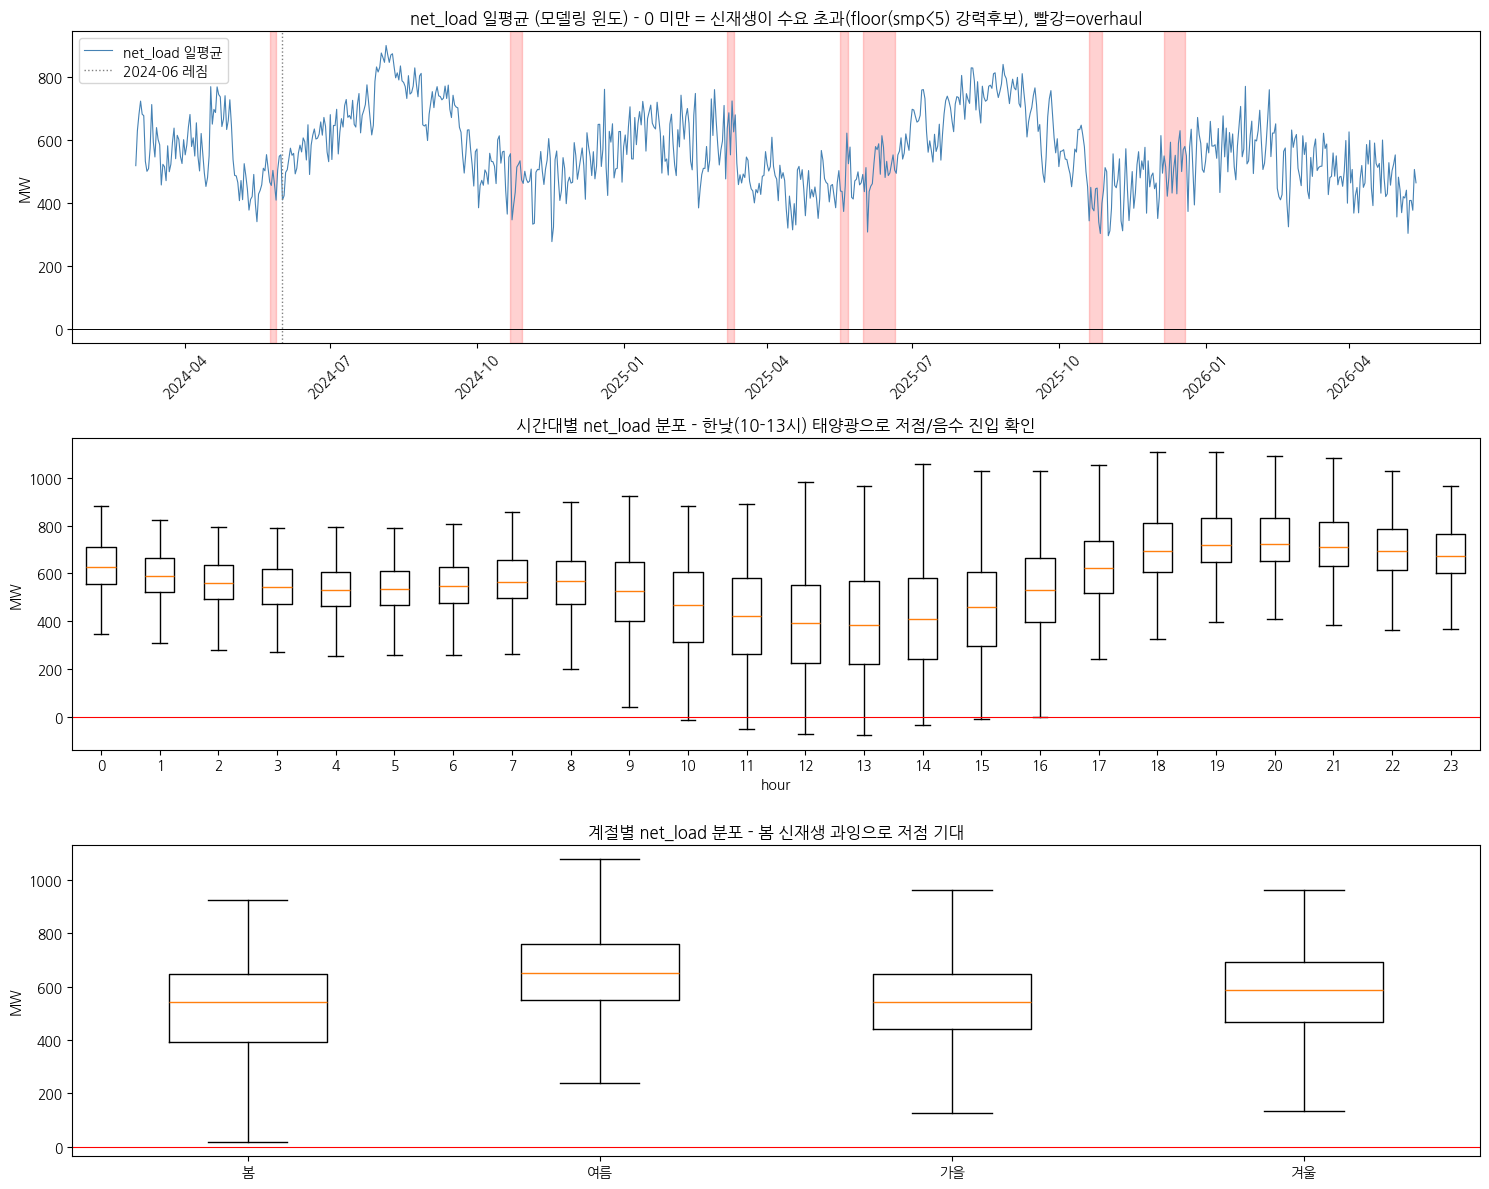

[Step 0] 셋업 / 변수 정의 / 데이터 점검 리포트
모델링 윈도   : 2024-03-01 00:00:00 ~ 2026-05-13 23:00:00  (19296 시간)
중복 timestamp: 0   결측 net_load: 0   결측 smp_jeju: 0
real_demand==0 행: 5  (renew_share 계산 시 inf->NaN 처리)

[net_load 분포 (MW)]
  평균 566.7  std 187.4  min -75.3  max 1646.7
  음(-) net_load 비율 : 0.11%   (한낮 10-13시 0.59% / 야간 02-05시 0.00%)
  한낮 평균 419.9  vs  야간 평균 539.8 MW

[renew_share = real_renew_gen / real_demand]
  평균 0.234  중앙 0.187  p95 0.631  max 1.158

[floor SMP(smp<5) 비율]
  P(smp_rt<5)   = 3.18%
  P(smp_jeju<5) = 1.62%
  smp_rt_neg_flag (any 15분 구간<0) = 4.22%
  DA-RT gap : 평균 +3.90  std 33.81  (Phase3: 봄 한낮 std 폭증)

[overhaul 윈도 커버리지]
  overhaul 시간 비율 : 8.46%   (1632 / 19296 시간)
  윈도에 걸친 이벤트 7건: 2024-05-24~2024-05-28, 2024-10-22~2024-10-29, 2025-03-07~2025-03-11, 2025-05-17~2025-05-22, 2025-05-31~2025-06-20, 2025-10-20~2025-10-28, 2025-12-06~2025-12-19

-> net_load 가 한낮/봄에 저점·음수로 내려가는 구조 확인. 다음 Step 1 에서 net_load 분위
   구간별 P(smp_rt<5)/P(smp_jeju<5) 곡선을 그려 zone 경계의 단서를 찾는다.


In [2]:
# ── Step 0 점검 플롯 : net_load 의 시간/계절 구조 + overhaul 커버리지 ──
nl_daily = df['net_load'].resample('D').mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

ax = axes[0]
ax.plot(nl_daily.index, nl_daily.values, color='steelblue', linewidth=0.8, label='net_load 일평균')
ax.axhline(0, color='black', linewidth=0.7)
ax.axvline(CUT_RT, color='gray', linestyle=':', linewidth=1, label='2024-06 레짐')
for s, e in events:                       # 모델링 윈도에 걸친 overhaul 구간만 음영
    if e >= df.index.min() and s <= df.index.max():
        ax.axvspan(s, e, color='red', alpha=0.18)
ax.set_title('net_load 일평균 (모델링 윈도) - 0 미만 = 신재생이 수요 초과(floor(smp<5) 강력후보), 빨강=overhaul')
ax.set_ylabel('MW'); ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
by_hour = [df.loc[df['hour'] == h, 'net_load'].values for h in range(24)]
ax.boxplot(by_hour, positions=range(24), showfliers=False)
ax.axhline(0, color='red', linewidth=0.8)
ax.set_title('시간대별 net_load 분포 - 한낮(10-13시) 태양광으로 저점/음수 진입 확인')
ax.set_xlabel('hour'); ax.set_ylabel('MW')

ax = axes[2]
by_season = [df.loc[df['season'] == s, 'net_load'].values for s in SEASON_ORDER]
ax.boxplot(by_season, showfliers=False)
ax.set_xticks(range(1, len(SEASON_ORDER) + 1)); ax.set_xticklabels(SEASON_ORDER)
ax.axhline(0, color='red', linewidth=0.8)
ax.set_title('계절별 net_load 분포 - 봄 신재생 과잉으로 저점 기대')
ax.set_ylabel('MW')

plt.tight_layout()
plt.show()

# ── Step 0 텍스트 리포트 (플롯과 동일 내용) ──
nl = df['net_load']
ov_win = df['overhaul_flag']
mid = df[df['hour'].between(10, 13)]['net_load']
nig = df[df['hour'].between(2, 5)]['net_load']
demand_zero = int((df['real_demand'] == 0).sum())

print('=' * 64)
print('[Step 0] 셋업 / 변수 정의 / 데이터 점검 리포트')
print('=' * 64)
print(f'모델링 윈도   : {df.index.min()} ~ {df.index.max()}  ({len(df)} 시간)')
print(f'중복 timestamp: {int(df.index.duplicated().sum())}   '
      f'결측 net_load: {int(nl.isna().sum())}   결측 smp_jeju: {int(df.smp_jeju.isna().sum())}')
print(f'real_demand==0 행: {demand_zero}  (renew_share 계산 시 inf->NaN 처리)')
print()
print('[net_load 분포 (MW)]')
print(f'  평균 {nl.mean():.1f}  std {nl.std():.1f}  min {nl.min():.1f}  max {nl.max():.1f}')
print(f'  음(-) net_load 비율 : {(nl < 0).mean()*100:.2f}%   '
      f'(한낮 10-13시 {(mid < 0).mean()*100:.2f}% / 야간 02-05시 {(nig < 0).mean()*100:.2f}%)')
print(f'  한낮 평균 {mid.mean():.1f}  vs  야간 평균 {nig.mean():.1f} MW')
print()
print('[renew_share = real_renew_gen / real_demand]')
print(f'  평균 {df.renew_share.mean():.3f}  중앙 {df.renew_share.median():.3f}  '
      f'p95 {df.renew_share.quantile(.95):.3f}  max {df.renew_share.max():.3f}')
print()
print('[floor SMP(smp<5) 비율]')
print(f'  P(smp_rt<5)   = {df.rt_neg.mean()*100:.2f}%')
print(f'  P(smp_jeju<5) = {df.da_neg.mean()*100:.2f}%')
if NEG_SEG:
    print(f'  {NEG_SEG} (any 15분 구간<0) = {df[NEG_SEG].astype(float).mean()*100:.2f}%')
print(f'  DA-RT gap : 평균 {df.gap.mean():+.2f}  std {df.gap.std():.2f}  '
      f'(Phase3: 봄 한낮 std 폭증)')
print()
print('[overhaul 윈도 커버리지]')
print(f'  overhaul 시간 비율 : {ov_win.mean()*100:.2f}%   '
      f'({int(ov_win.sum())} / {len(ov_win)} 시간)')
ev_in = [(s.date(), e.date()) for s, e in events
         if e >= df.index.min() and s <= df.index.max()]
print(f'  윈도에 걸친 이벤트 {len(ev_in)}건: ' +
      ', '.join(f'{s}~{e}' for s, e in ev_in))
print()
print('-> net_load 가 한낮/봄에 저점·음수로 내려가는 구조 확인. 다음 Step 1 에서 net_load 분위')
print('   구간별 P(smp_rt<5)/P(smp_jeju<5) 곡선을 그려 zone 경계의 단서를 찾는다.')

## Step 1 - net_load <-> SMP 조건부 구조 (floor(smp<5) 확률 곡선)

**목표**: Phase 3 교훈(시간별 레벨 Pearson 상관 0.59 -> 차분 0.09 = 추세 허위)을 피해,
net_load **분위 구간(20분위)** 별로 평균 SMP 와 **P(smp_rt<5)·P(smp_jeju<5)** 를 본다.
RT 의 음전환이 net_load 0 이 아니라 *양(+)* 구간에서 시작함을 확인하고, P 가 상승하는
net_load 띠(= 다음 Step 3 의 zone 경계 단서)를 수치로 찾는다. 단조 참고로 Spearman 만 병기.

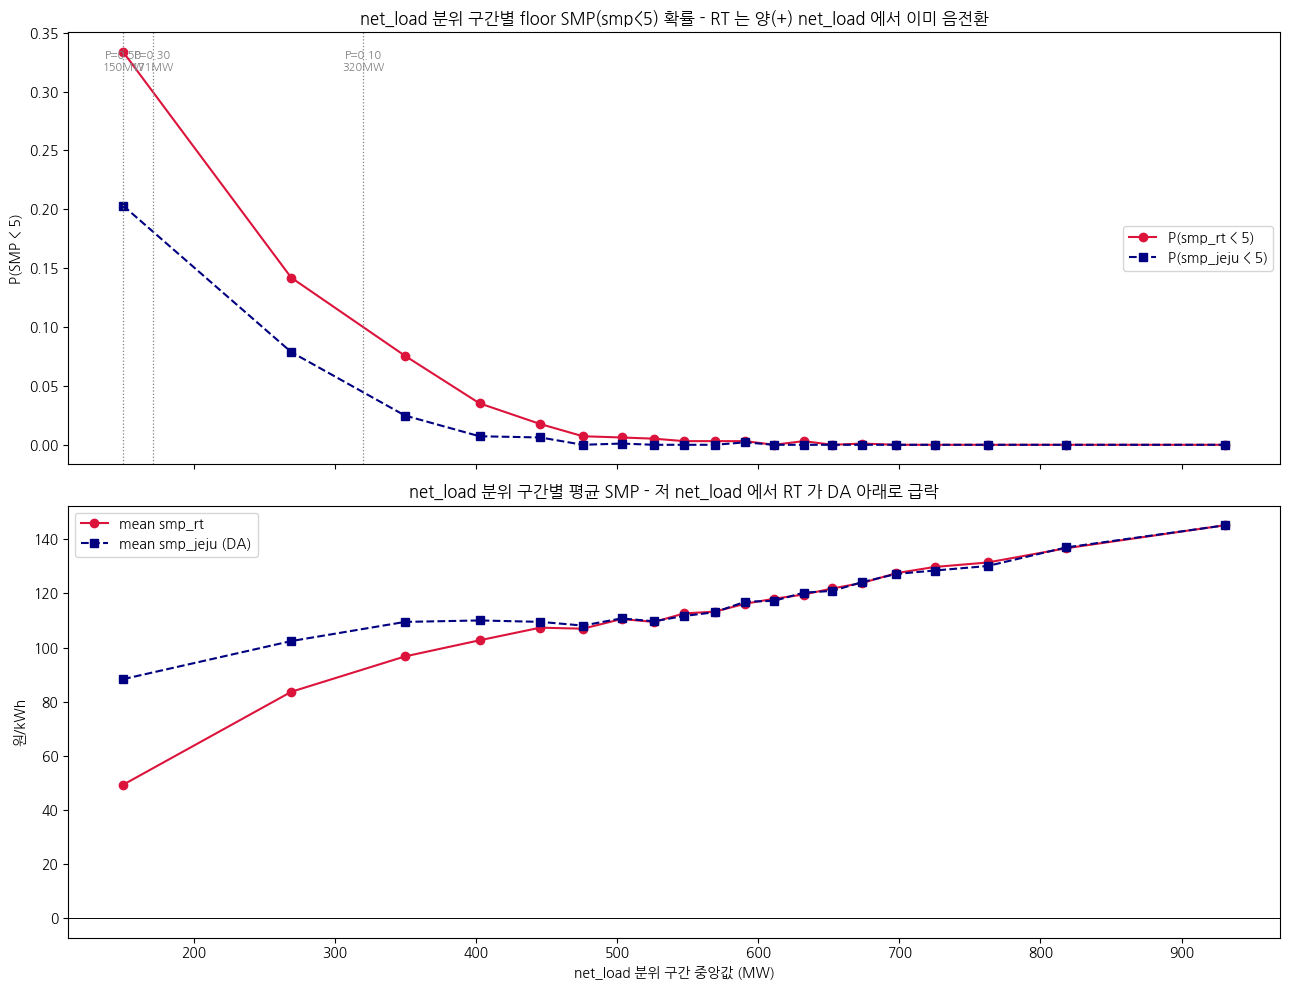

[Step 1] net_load <-> SMP 조건부 구조 리포트
  n  nl_lo  nl_hi  nl_med  rt_mean  da_mean  P_rt_neg  P_da_neg  gap_mean
965  -75.3  214.3   150.1     49.3     88.3      33.4      20.3      39.0
965  214.5  311.9   269.2     83.6    102.4      14.2       7.9      18.8
965  311.9  377.8   349.7     96.7    109.5       7.6       2.5      12.8
965  377.9  425.6   402.6    102.7    110.0       3.5       0.7       7.3
964  425.8  461.8   445.7    107.4    109.5       1.8       0.6       2.1
965  461.8  490.0   475.8    107.0    108.1       0.7       0.0       1.2
965  490.0  515.5   503.2    110.5    110.8       0.6       0.1       0.2
965  515.5  537.1   526.3    109.5    109.7       0.5       0.0       0.2
964  537.1  557.8   547.5    112.6    111.7       0.3       0.0      -0.9
965  557.8  580.2   569.3    113.3    113.1       0.3       0.0      -0.2
965  580.2  601.1   590.8    116.2    116.9       0.3       0.2       0.7
965  601.1  621.8   611.2    118.0    117.3       0.0       0.0      -0.8
9

In [3]:
# net_load 20분위 구간 (qcut). 동률로 경계 줄면 duplicates='drop'
N_BINS = 20
df['nl_bin'] = pd.qcut(df['net_load'], N_BINS, labels=False, duplicates='drop')


def neg_by_netload():
    g = df.groupby('nl_bin')
    t = pd.DataFrame({
        'n':        g.size(),
        'nl_lo':    g['net_load'].min(),
        'nl_hi':    g['net_load'].max(),
        'nl_med':   g['net_load'].median(),
        'rt_mean':  g[TARGET].mean(),
        'da_mean':  g['smp_jeju'].mean(),
        'P_rt_neg': g['rt_neg'].mean(),
        'P_da_neg': g['da_neg'].mean(),
        'gap_mean': g['gap'].mean(),
    }).sort_values('nl_med').reset_index(drop=True)
    return t


tab = neg_by_netload()


def nl_at_p(t, level):
    # net_load(분위중앙) -> P(smp_rt<5) 보간곡선에서 P 가 level 을 처음 밑도는 net_load.
    # net_load 가 커질수록 P 는 감소하므로 그 교차점이 zone 경계 후보가 된다.
    x = t['nl_med'].values
    y = t['P_rt_neg'].values
    grid = np.linspace(x.min(), x.max(), 2000)
    p = np.interp(grid, x, y)             # x(net_load) 오름차순이라 안전
    hit = np.where(p <= level)[0]
    return float(grid[hit[0]]) if len(hit) else float(x.max())


sp_rt = df[['net_load', TARGET]].corr(method='spearman').iloc[0, 1]
sp_da = df[['net_load', 'smp_jeju']].corr(method='spearman').iloc[0, 1]

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.plot(tab['nl_med'], tab['P_rt_neg'], 'o-', color='crimson', label='P(smp_rt < 5)')
ax.plot(tab['nl_med'], tab['P_da_neg'], 's--', color='navy', label='P(smp_jeju < 5)')
for lv in (0.10, 0.30, 0.50):
    xv = nl_at_p(tab, lv)
    ax.axvline(xv, color='gray', linestyle=':', linewidth=0.9)
    ax.text(xv, ax.get_ylim()[1] * 0.96, f'P={lv:.2f}\n{xv:.0f}MW',
            fontsize=8, ha='center', va='top', color='gray')
ax.set_title('net_load 분위 구간별 floor SMP(smp<5) 확률 - RT 는 양(+) net_load 에서 이미 음전환')
ax.set_ylabel('P(SMP < 5)'); ax.legend(loc='center right')

ax = axes[1]
ax.plot(tab['nl_med'], tab['rt_mean'], 'o-', color='crimson', label='mean smp_rt')
ax.plot(tab['nl_med'], tab['da_mean'], 's--', color='navy', label='mean smp_jeju (DA)')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('net_load 분위 구간별 평균 SMP - 저 net_load 에서 RT 가 DA 아래로 급락')
ax.set_xlabel('net_load 분위 구간 중앙값 (MW)'); ax.set_ylabel('원/kWh')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print('=' * 64)
print('[Step 1] net_load <-> SMP 조건부 구조 리포트')
print('=' * 64)
show = tab.copy()
show['P_rt_neg'] = (show['P_rt_neg'] * 100).round(1)
show['P_da_neg'] = (show['P_da_neg'] * 100).round(1)
print(show[['n', 'nl_lo', 'nl_hi', 'nl_med', 'rt_mean', 'da_mean',
            'P_rt_neg', 'P_da_neg', 'gap_mean']].round(1).to_string(index=False))
print('  (P_rt_neg / P_da_neg 단위 = %)')
print()
print(f'Spearman(net_load, smp_rt)   = {sp_rt:+.3f}')
print(f'Spearman(net_load, smp_jeju) = {sp_da:+.3f}')
print('  (단조 상관 참고치 - 해석 핵심은 위 조건부 표/곡선. Phase3: 선형상관은 추세허위)')
print()
print('[P(smp_rt<5) 가 특정 수준을 지나는 net_load (근사, zone 경계 단서)]')
for lv in (0.05, 0.10, 0.20, 0.30, 0.50):
    print(f'  P={lv:.2f}  ->  net_load ~ {nl_at_p(tab, lv):.0f} MW')
print(f'  P(smp_rt<5) 최대(최저 net_load 구간) = {tab["P_rt_neg"].max()*100:.1f}%')
print()
print('-> RT 의 음전환은 net_load 0 이 아니라 *양(+)* 구간에서 시작(화력 최소출력/입찰하한).')
print('   P 가 완만->급상승으로 꺾이는 net_load 띠 = 다음 Step 3 zone B(전이) 후보.')

## Step 2 - 계절 x 시간 조건화 (히트맵)

**목표**: Phase 3 의 "봄 한낮(10-13시) DA-RT 격차 폭증"을 net_load 와 함께 한 화면에서 본다.
계절(4) x 시간(24) 격자에서 ① P(smp_rt<5) ② 평균 net_load ③ DA-RT 격차 평균 ④ 격차 std
를 히트맵으로. floor(smp<5)·격차 변동이 어디(계절x시간)에 몰리고 그곳 net_load 가 얼마나 낮은지 매칭.

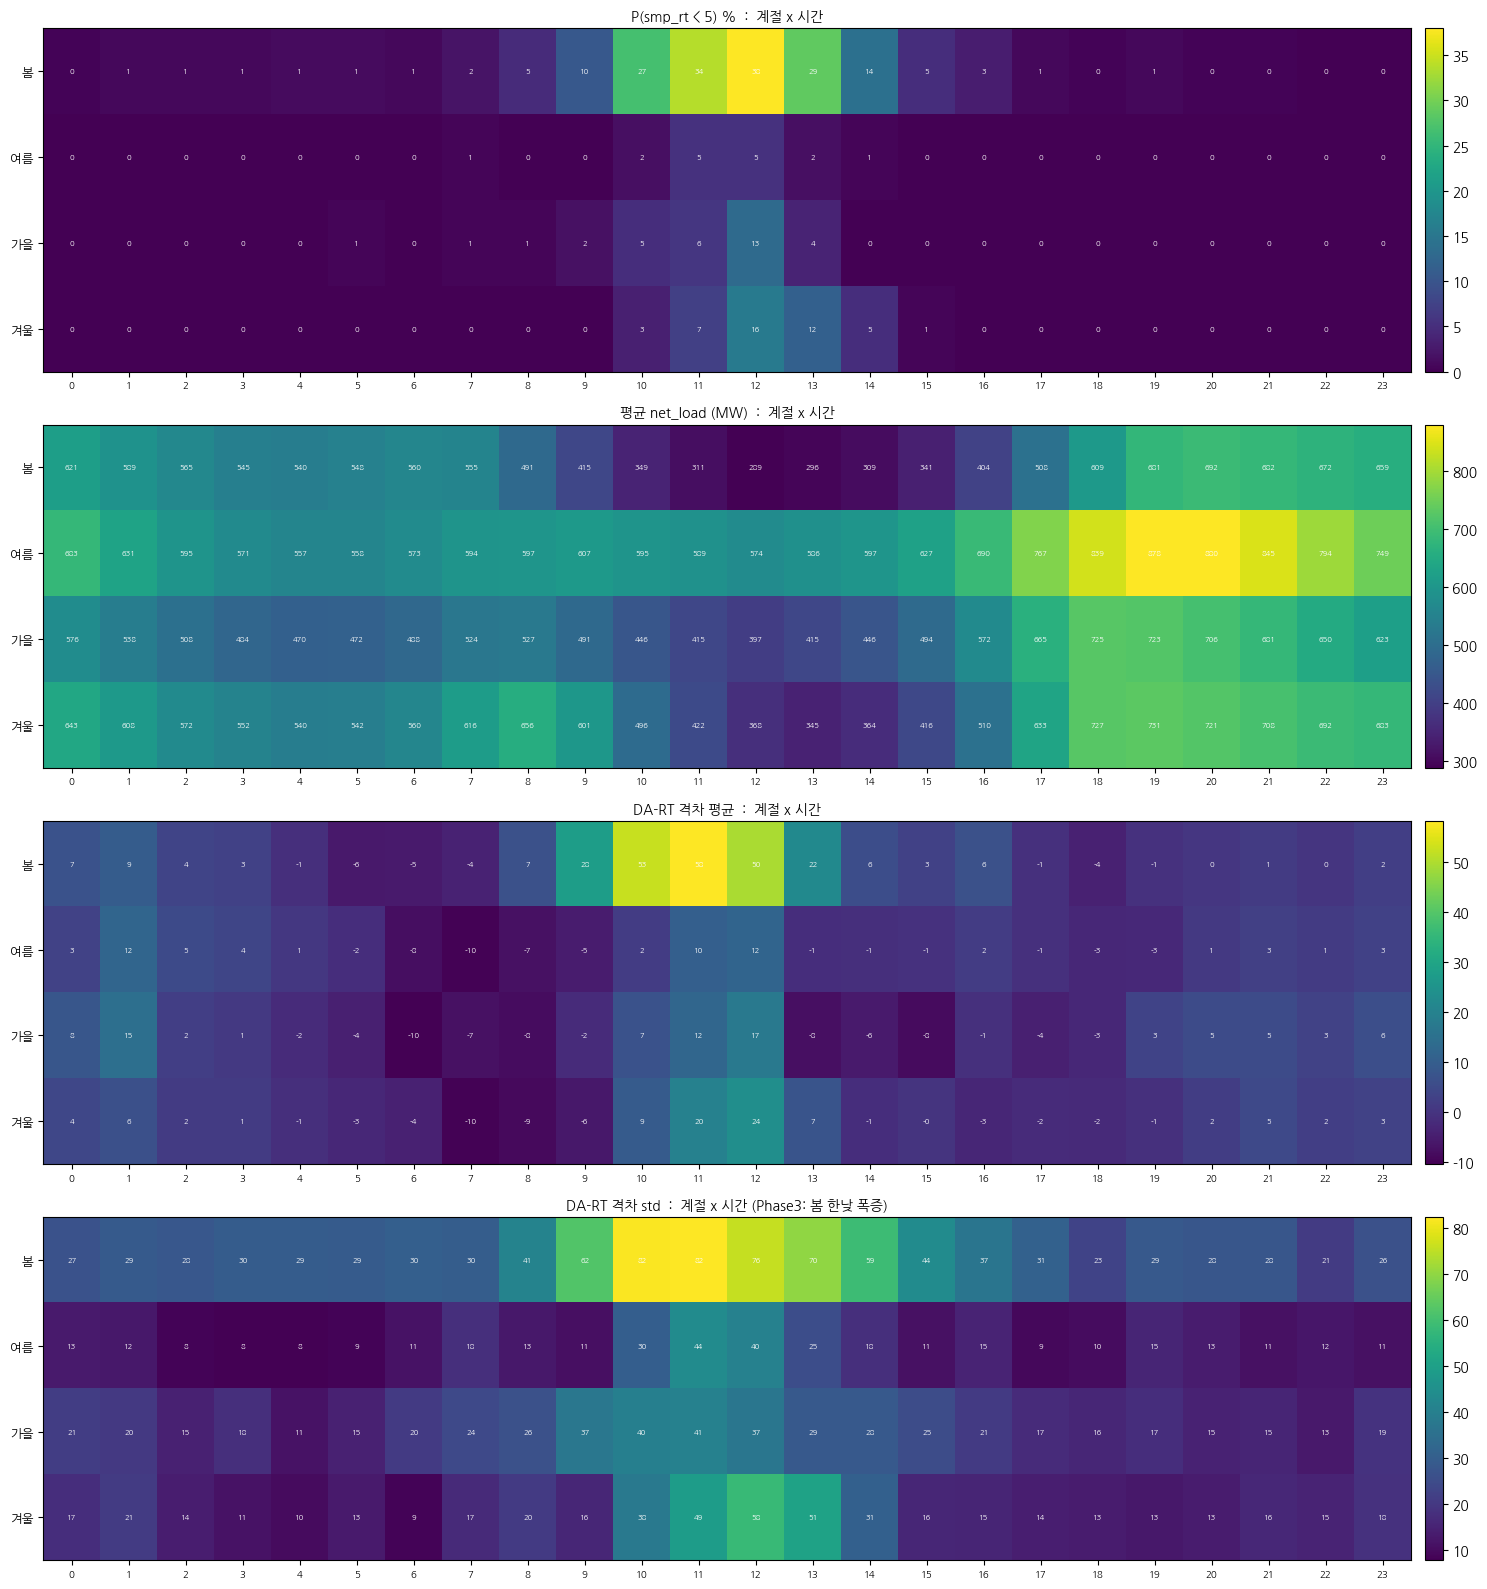

[Step 2] 계절 x 시간 조건화 리포트
[P(smp_rt<5) 최고 셀 (계절, 시간 -> %)]
  봄 12시  P(rt<5)=38.0%   평균 net_load=289MW
  봄 11시  P(rt<5)=33.7%   평균 net_load=311MW
  봄 13시  P(rt<5)=28.7%   평균 net_load=296MW
  봄 10시  P(rt<5)=26.7%   평균 net_load=349MW
  겨울 12시  P(rt<5)=15.6%   평균 net_load=368MW
  봄 14시  P(rt<5)=14.0%   평균 net_load=309MW
  가을 12시  P(rt<5)=13.2%   평균 net_load=397MW
  겨울 13시  P(rt<5)=11.7%   평균 net_load=345MW

[DA-RT 격차 std 최고 셀 (계절, 시간 -> std)]
  봄 11시  gap std=82   평균 net_load=311MW   P(rt<5)=33.7%
  봄 10시  gap std=82   평균 net_load=349MW   P(rt<5)=26.7%
  봄 12시  gap std=76   평균 net_load=289MW   P(rt<5)=38.0%
  봄 13시  gap std=70   평균 net_load=296MW   P(rt<5)=28.7%
  봄 09시  gap std=62   평균 net_load=415MW   P(rt<5)=10.5%
  봄 14시  gap std=59   평균 net_load=309MW   P(rt<5)=14.0%
  겨울 12시  gap std=58   평균 net_load=368MW   P(rt<5)=15.6%
  겨울 13시  gap std=51   평균 net_load=345MW   P(rt<5)=11.7%

야간(02-05) 평균 P(rt<5) = 0.3%   한낮(10-13) = 12.9%

-> floor(smp<5)·격차변동이 봄/가을 한낮에 집중 + 그 셀의 net_load 가 최저.
  

In [4]:
def pv(val, agg):
    return (df.pivot_table(index='season', columns='hour', values=val, aggfunc=agg)
              .reindex(SEASON_ORDER))


def heat(ax, M, title, fmt):
    A = M.values.astype(float)
    Am = np.ma.masked_invalid(A)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad('lightgray')
    im = ax.imshow(Am, aspect='auto', cmap=cmap)
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels(M.columns, fontsize=7)
    ax.set_yticks(range(M.shape[0]))
    ax.set_yticklabels(M.index, fontsize=9)
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            v = A[r, c]
            if np.isfinite(v):
                ax.text(c, r, format(v, fmt), ha='center', va='center',
                        fontsize=5.5, color='white')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.01)


Prt   = pv('rt_neg', 'mean') * 100
NLm   = pv('net_load', 'mean')
Gm    = pv('gap', 'mean')
Gs    = pv('gap', 'std')

fig, axes = plt.subplots(4, 1, figsize=(15, 16))
heat(axes[0], Prt, 'P(smp_rt < 5) %  :  계절 x 시간', '.0f')
heat(axes[1], NLm, '평균 net_load (MW)  :  계절 x 시간', '.0f')
heat(axes[2], Gm,  'DA-RT 격차 평균  :  계절 x 시간', '.0f')
heat(axes[3], Gs,  'DA-RT 격차 std  :  계절 x 시간 (Phase3: 봄 한낮 폭증)', '.0f')
plt.tight_layout()
plt.show()


def topcells(M, k, asc):
    return M.stack().sort_values(ascending=asc).head(k)


print('=' * 64)
print('[Step 2] 계절 x 시간 조건화 리포트')
print('=' * 64)
print('[P(smp_rt<5) 최고 셀 (계절, 시간 -> %)]')
for (s, h), v in topcells(Prt, 8, False).items():
    print(f'  {s} {h:02d}시  P(rt<5)={v:.1f}%   평균 net_load={NLm.loc[s, h]:.0f}MW')
print()
print('[DA-RT 격차 std 최고 셀 (계절, 시간 -> std)]')
for (s, h), v in topcells(Gs, 8, False).items():
    print(f'  {s} {h:02d}시  gap std={v:.0f}   평균 net_load={NLm.loc[s, h]:.0f}MW   '
          f'P(rt<5)={Prt.loc[s, h]:.1f}%')
print()
print(f'야간(02-05) 평균 P(rt<5) = '
      f'{Prt[[c for c in Prt.columns if 2 <= c <= 5]].mean(axis=1).mean():.1f}%   '
      f'한낮(10-13) = '
      f'{Prt[[c for c in Prt.columns if 10 <= c <= 13]].mean(axis=1).mean():.1f}%')
print()
print('-> floor(smp<5)·격차변동이 봄/가을 한낮에 집중 + 그 셀의 net_load 가 최저.')
print('   = net_load 가 zone 경계를 넘는 시점이 곧 봄 한낮 -> Step 3 에서 경계 수치화.')

## Step 3 - 데이터기반 zone 경계 / 프로파일

**목표**: Step 1 의 P(smp_rt<5) 곡선에서 **데이터기반으로 net_load 경계**를 뽑아 zone A/B/C/D
를 나눈다. P 기준은 곡선 범위에 맞춰 적응(0.85*Pmax 클램프, 퇴화 시 net_load 분위 폴백).
각 zone 의 n·음비율·격차·renew_share·firm_cap·overhaul·계절구성을 표로 만들고, **관측 거동으로
zone 을 명명**(A=안정 / B=전이=보정핵심 / C=빈발 / D=상시). A~D 라벨은 가설, 의미는 표가 결정.

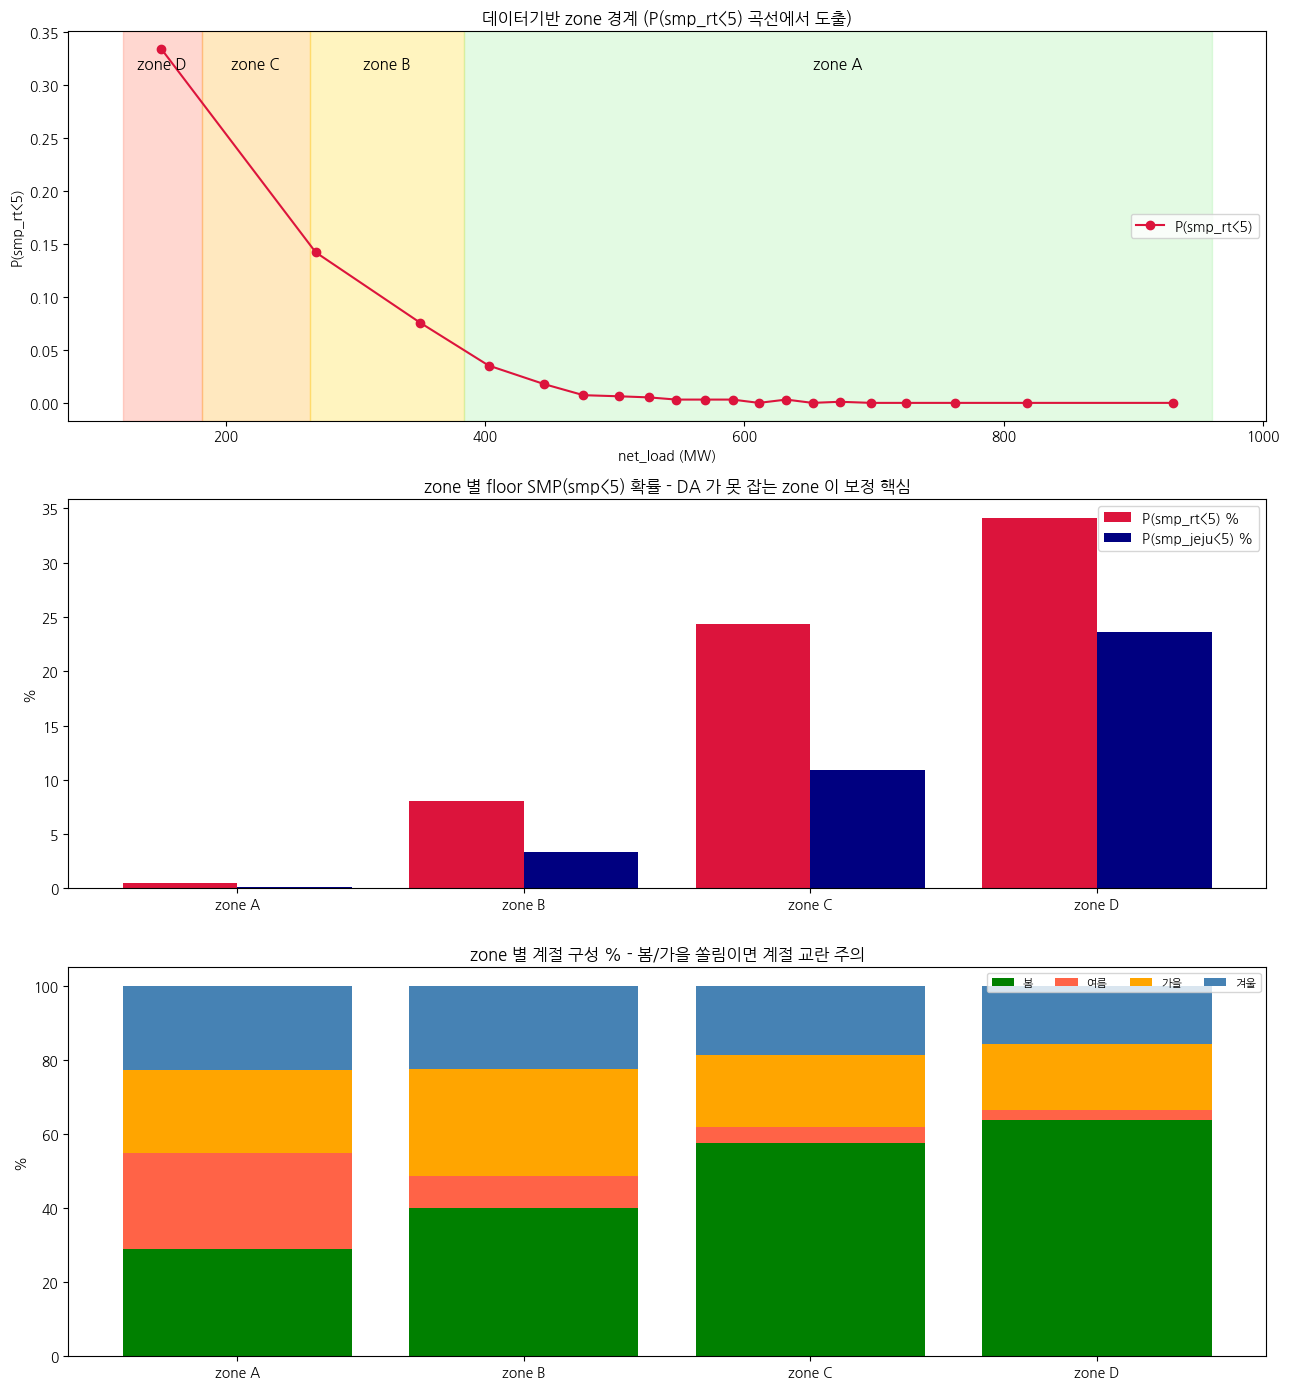

[Step 3] 데이터기반 zone 경계 / 프로파일 리포트
P(rt<5) 최대 33.4% (최저 net_load 구간)  -> 사용 P 기준 [0.05, 0.15, 0.284] (0.85*Pmax 클램프)
net_load 경계(MW) : D < 181.3 <= C < 264.5 <= B < 383.6 <= A

          n  share_%   nl_lo    nl_hi  P_rt_neg%  P_da_neg%  gap_mean  gap_std  renew_sh  firm_cap  overh_%
zone                                                                                                       
A     16295    84.45  383.63  1646.73       0.47       0.10      0.36    21.99      0.17   1246.55     7.66
B      1598     8.28  264.53   383.52       8.01       3.38     13.09    51.41      0.46   1172.47    13.70
C       703     3.64  181.48   264.43      24.32      10.95     32.98    77.68      0.61   1156.48    14.79
D       700     3.63  -75.29   181.13      34.14      23.57     36.08    76.19      0.78   1144.23     8.71

[zone 별 계절 구성 %]
season    가을    겨울     봄    여름
zone                          
A       22.4  22.8  28.9  26.0
B       29.0  22.4  39.9   8.7
C       19.6  18.6  57.6   4.1
D  

In [5]:
# Step 1 의 tab / nl_at_p 재사용 (노트북은 위->아래 순차 실행 가정)
Pmax = float(tab['P_rt_neg'].max())
raw_levels = [0.05, 0.15, 0.35]                       # A|B , B|C , C|D 경계용 P 기준
levels = [min(l, 0.85 * Pmax) for l in raw_levels]    # 곡선 범위 넘으면 클램프(퇴화 방지)
nl_cuts = sorted({round(nl_at_p(tab, lv), 1) for lv in levels})
if len(nl_cuts) < 3:                                  # 퇴화 시 net_load 분위 폴백
    q = df['net_load'].quantile([0.05, 0.20, 0.50]).round(1).tolist()
    nl_cuts = sorted(set(q))
    while len(nl_cuts) < 3:
        nl_cuts = sorted(set(nl_cuts + [nl_cuts[-1] + 1.0]))
nl_cuts = nl_cuts[:3]

edges  = [-np.inf, nl_cuts[0], nl_cuts[1], nl_cuts[2], np.inf]
labels = ['D', 'C', 'B', 'A']                         # net_load 낮음->높음 = D->A
df['zone'] = pd.cut(df['net_load'], bins=edges, labels=labels)
ZONE_ORDER = ['A', 'B', 'C', 'D']

g = df.groupby('zone', observed=False)
prof = pd.DataFrame({
    'n':          g.size(),
    'share_%':    g.size() / len(df) * 100,
    'nl_lo':      g['net_load'].min(),
    'nl_hi':      g['net_load'].max(),
    'P_rt_neg%':  g['rt_neg'].mean() * 100,
    'P_da_neg%':  g['da_neg'].mean() * 100,
    'gap_mean':   g['gap'].mean(),
    'gap_std':    g['gap'].std(),
    'renew_sh':   g['renew_share'].mean(),
    'firm_cap':   g['firm_cap'].mean(),
    'overh_%':    g['overhaul_flag'].mean() * 100,
}).reindex(ZONE_ORDER)

seas = (df.groupby(['zone', 'season'], observed=False).size()
          .unstack(fill_value=0).reindex(ZONE_ORDER))
seas_pct = seas.div(seas.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

ax = axes[0]
ax.plot(tab['nl_med'], tab['P_rt_neg'], 'o-', color='crimson', label='P(smp_rt<5)')
zcolor = {'A': 'lightgreen', 'B': 'gold', 'C': 'orange', 'D': 'tomato'}
prev = float(tab['nl_med'].min()) - 30
seg = list(nl_cuts) + [float(tab['nl_med'].max()) + 30]
for lab, hi in zip(['D', 'C', 'B', 'A'], seg):
    ax.axvspan(prev, hi, color=zcolor[lab], alpha=0.25)
    ax.text((prev + hi) / 2, ax.get_ylim()[1] * 0.9, f'zone {lab}',
            ha='center', fontsize=11)
    prev = hi
ax.set_title('데이터기반 zone 경계 (P(smp_rt<5) 곡선에서 도출)')
ax.set_xlabel('net_load (MW)'); ax.set_ylabel('P(smp_rt<5)')
ax.legend(loc='center right')

ax = axes[1]
x = np.arange(4)
ax.bar(x - 0.2, prof['P_rt_neg%'].values, 0.4, color='crimson', label='P(smp_rt<5) %')
ax.bar(x + 0.2, prof['P_da_neg%'].values, 0.4, color='navy', label='P(smp_jeju<5) %')
ax.set_xticks(x); ax.set_xticklabels([f'zone {z}' for z in ZONE_ORDER])
ax.set_title('zone 별 floor SMP(smp<5) 확률 - DA 가 못 잡는 zone 이 보정 핵심')
ax.set_ylabel('%'); ax.legend()

ax = axes[2]
bottom = np.zeros(4)
scol = {'봄': 'green', '여름': 'tomato', '가을': 'orange', '겨울': 'steelblue'}
for s in SEASON_ORDER:
    vals = seas_pct[s].reindex(ZONE_ORDER).fillna(0).values
    ax.bar(range(4), vals, bottom=bottom, label=s, color=scol[s])
    bottom += vals
ax.set_xticks(range(4)); ax.set_xticklabels([f'zone {z}' for z in ZONE_ORDER])
ax.set_title('zone 별 계절 구성 % - 봄/가을 쏠림이면 계절 교란 주의')
ax.set_ylabel('%'); ax.legend(ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

print('=' * 64)
print('[Step 3] 데이터기반 zone 경계 / 프로파일 리포트')
print('=' * 64)
print(f'P(rt<5) 최대 {Pmax*100:.1f}% (최저 net_load 구간)  '
      f'-> 사용 P 기준 {[round(l, 3) for l in levels]} (0.85*Pmax 클램프)')
print(f'net_load 경계(MW) : D < {nl_cuts[0]} <= C < {nl_cuts[1]} '
      f'<= B < {nl_cuts[2]} <= A')
print()
print(prof.round(2).to_string())
print()
print('[zone 별 계절 구성 %]')
print(seas_pct.round(1).to_string())
print()
print('-> zone 명명(관측 거동 기반):')
print('   A=고 net_load 안정(floor 거의 0, DA 그대로) / B=전이(P 급상승, DA 판정 애매=보정 핵심)')
print('   C=저 net_load floor 빈발(P~24%) / D=초저 net_load 최빈(P 상한 ~34%, 비결정적)')
print('   Phase 6 = zone B/C/D 잔여를 태양광 중심 실시간 날씨로 (zone내 분위·계절x시간 통제).')

## Step 4-1, 4-2 - overhaul 효과 (zone C+D, 계절 x 시간 통제)

**목표**: 사용자 가설 = "저 net_load(zone C/D) 라도 overhaul(화력 정비로 빠짐)이면 RT 가
음(-)으로 덜 간다(바닥이 올라간다)". Phase 4 는 봄 쏠림으로 교란됨 -> 여기서는 **zone C+D 만**
보고 **계절·시간대(daypart)로 통제**해 P(smp_rt<5)|overhaul vs |정상 을 비교. overhaul 표본의
net_load 분포가 정상과 비슷한지(편향 점검)도 함께 본다. baseline center=True 한계는 명시.

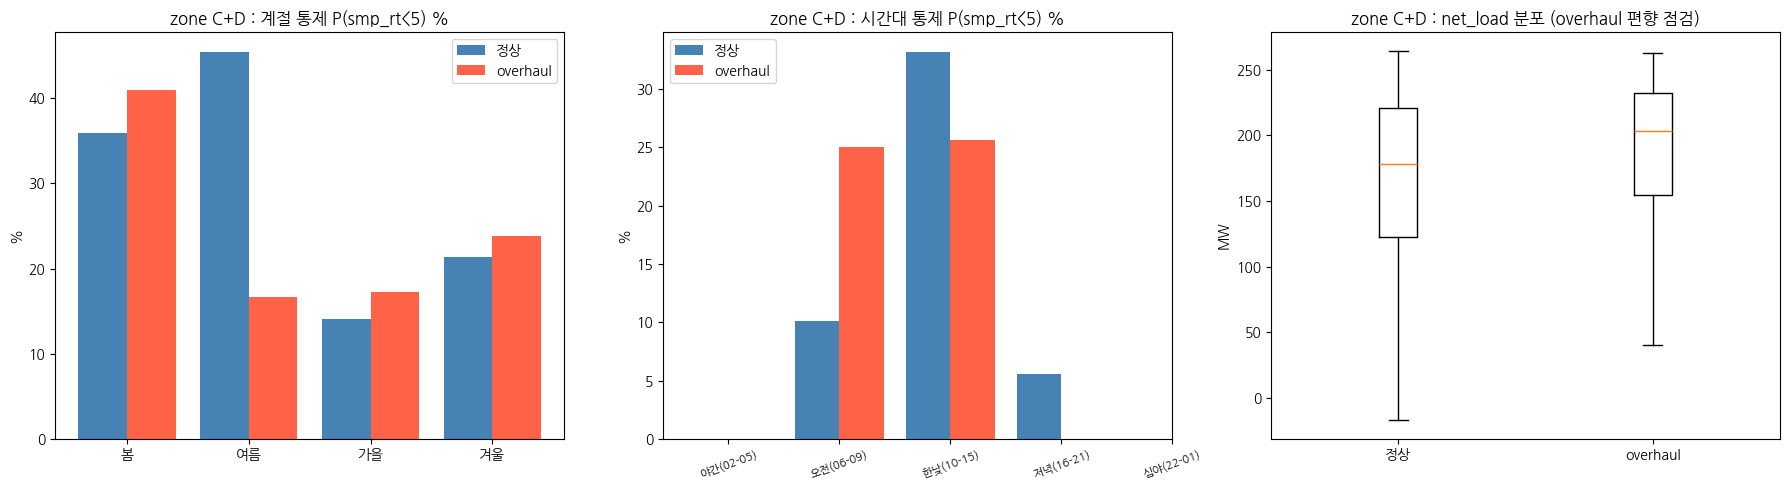

[Step 4-1] overhaul 효과, RT SMP 관점 (zone C+D, 계절x시간 통제) 리포트
zone C+D 표본 : 1403  (overhaul 165 / 정상 1238)
net_load 평균 : overhaul 183.8 vs 정상 168.1 MW (가까울수록 net_load 교란 적음)

[계절 통제 P(smp_rt<5) %  (n: overhaul/정상)]
  봄    overhaul   40.9  vs 정상   35.9   (n 44/808)
  여름   overhaul   16.7  vs 정상   45.5   (n 36/11)
  가을   overhaul   17.2  vs 정상   14.1   (n 64/199)
  겨울   overhaul   23.8  vs 정상   21.4   (n 21/220)

[시간대 통제 P(smp_rt<5) %  (n: overhaul/정상)]
  야간(02-05)    overhaul    0.0  vs 정상    0.0   (n 6/16)
  오전(06-09)    overhaul   25.0  vs 정상   10.1   (n 8/69)
  한낮(10-15)    overhaul   25.7  vs 정상   33.2   (n 148/1081)
  저녁(16-21)    overhaul    0.0  vs 정상    5.6   (n 3/72)
  심야(22-01)    overhaul    nan  vs 정상    nan   (n 0/0)

[계절x시간 셀 통제] 평균 P(rt<5) 차이(overhaul - 정상) = -1.2%p (표본>=5 인 5개 셀, 작은쪽 표본 가중)

-> 차이가 음(-)이면 가설 지지(overhaul 시 floor(smp<5) 감소). 표본 적고 baseline
   center=True(회고용) -> 모델 피처화 시 trailing 재계산 + 약신호로만 사용.


In [6]:
cd = df[df['zone'].isin(['C', 'D'])].copy()


def daypart(h):
    if 2 <= h <= 5:
        return '야간(02-05)'
    if 6 <= h <= 9:
        return '오전(06-09)'
    if 10 <= h <= 15:
        return '한낮(10-15)'
    if 16 <= h <= 21:
        return '저녁(16-21)'
    return '심야(22-01)'


DP_ORDER = ['야간(02-05)', '오전(06-09)', '한낮(10-15)', '저녁(16-21)', '심야(22-01)']

if len(cd):
    cd['daypart'] = cd['hour'].map(daypart)
    ov = cd[cd['overhaul_flag']]
    nov = cd[~cd['overhaul_flag']]

    def pneg_by(col, order):
        sub_o = cd[cd['overhaul_flag']]
        sub_n = cd[~cd['overhaul_flag']]
        out = pd.DataFrame({
            'overhaul': sub_o.groupby(col)['rt_neg'].mean() * 100,
            '정상':     sub_n.groupby(col)['rt_neg'].mean() * 100,
            'n_ov':     sub_o.groupby(col)['rt_neg'].size(),
            'n_nov':    sub_n.groupby(col)['rt_neg'].size(),
        }).reindex(order)
        out[['n_ov', 'n_nov']] = out[['n_ov', 'n_nov']].fillna(0).astype(int)
        return out

    by_season = pneg_by('season', SEASON_ORDER)
    by_dp = pneg_by('daypart', DP_ORDER)

    # 계절 x 시간 셀 단위 통제: 둘 다 표본>=5 인 셀만, 작은쪽 표본 가중 평균차이
    rows = []
    for (s, d), g2 in cd.groupby(['season', 'daypart']):
        o = g2[g2['overhaul_flag']]['rt_neg']
        nn = g2[~g2['overhaul_flag']]['rt_neg']
        if len(o) >= 5 and len(nn) >= 5:
            rows.append((o.mean() - nn.mean(), min(len(o), len(nn))))
    if rows:
        d_arr = np.array([r[0] for r in rows])
        w_arr = np.array([r[1] for r in rows])
        ctrl_diff = float(np.average(d_arr, weights=w_arr)) * 100
        n_cells = len(rows)
    else:
        ctrl_diff, n_cells = float('nan'), 0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    x = np.arange(len(SEASON_ORDER))
    ax.bar(x - 0.2, by_season['정상'].values, 0.4, color='steelblue', label='정상')
    ax.bar(x + 0.2, by_season['overhaul'].values, 0.4, color='tomato', label='overhaul')
    ax.set_xticks(x); ax.set_xticklabels(SEASON_ORDER)
    ax.set_title('zone C+D : 계절 통제 P(smp_rt<5) %')
    ax.set_ylabel('%'); ax.legend()

    ax = axes[1]
    x = np.arange(len(DP_ORDER))
    ax.bar(x - 0.2, by_dp['정상'].values, 0.4, color='steelblue', label='정상')
    ax.bar(x + 0.2, by_dp['overhaul'].values, 0.4, color='tomato', label='overhaul')
    ax.set_xticks(x); ax.set_xticklabels(DP_ORDER, rotation=20, fontsize=8)
    ax.set_title('zone C+D : 시간대 통제 P(smp_rt<5) %')
    ax.set_ylabel('%'); ax.legend()

    ax = axes[2]
    if len(ov) and len(nov):
        ax.boxplot([nov['net_load'].values, ov['net_load'].values], showfliers=False)
        ax.set_xticks([1, 2]); ax.set_xticklabels(['정상', 'overhaul'])
        ax.set_ylabel('MW')
    else:
        ax.text(0.5, 0.5, 'overhaul/정상 표본 부족', ha='center', va='center')
    ax.set_title('zone C+D : net_load 분포 (overhaul 편향 점검)')

    plt.tight_layout()
    plt.show()

    print('=' * 64)
    print('[Step 4-1] overhaul 효과, RT SMP 관점 (zone C+D, 계절x시간 통제) 리포트')
    print('=' * 64)
    print(f'zone C+D 표본 : {len(cd)}  (overhaul {len(ov)} / 정상 {len(nov)})')
    if len(ov) and len(nov):
        print(f'net_load 평균 : overhaul {ov.net_load.mean():.1f} vs '
              f'정상 {nov.net_load.mean():.1f} MW (가까울수록 net_load 교란 적음)')
    print()
    print('[계절 통제 P(smp_rt<5) %  (n: overhaul/정상)]')
    for s in SEASON_ORDER:
        r = by_season.loc[s]
        print(f'  {s:3s}  overhaul {r["overhaul"]:6.1f}  vs 정상 {r["정상"]:6.1f}   '
              f'(n {int(r["n_ov"])}/{int(r["n_nov"])})')
    print()
    print('[시간대 통제 P(smp_rt<5) %  (n: overhaul/정상)]')
    for d in DP_ORDER:
        r = by_dp.loc[d]
        print(f'  {d:11s}  overhaul {r["overhaul"]:6.1f}  vs 정상 {r["정상"]:6.1f}   '
              f'(n {int(r["n_ov"])}/{int(r["n_nov"])})')
    print()
    print(f'[계절x시간 셀 통제] 평균 P(rt<5) 차이(overhaul - 정상) = {ctrl_diff:+.1f}%p '
          f'(표본>=5 인 {n_cells}개 셀, 작은쪽 표본 가중)')
    print()
    print('-> 차이가 음(-)이면 가설 지지(overhaul 시 floor(smp<5) 감소). 표본 적고 baseline')
    print('   center=True(회고용) -> 모델 피처화 시 trailing 재계산 + 약신호로만 사용.')
else:
    ctrl_diff, n_cells = float('nan'), 0
    print('[Step 4] zone C+D 표본이 없음 - Step 3 경계가 퇴화. 경계 재조정 필요.')

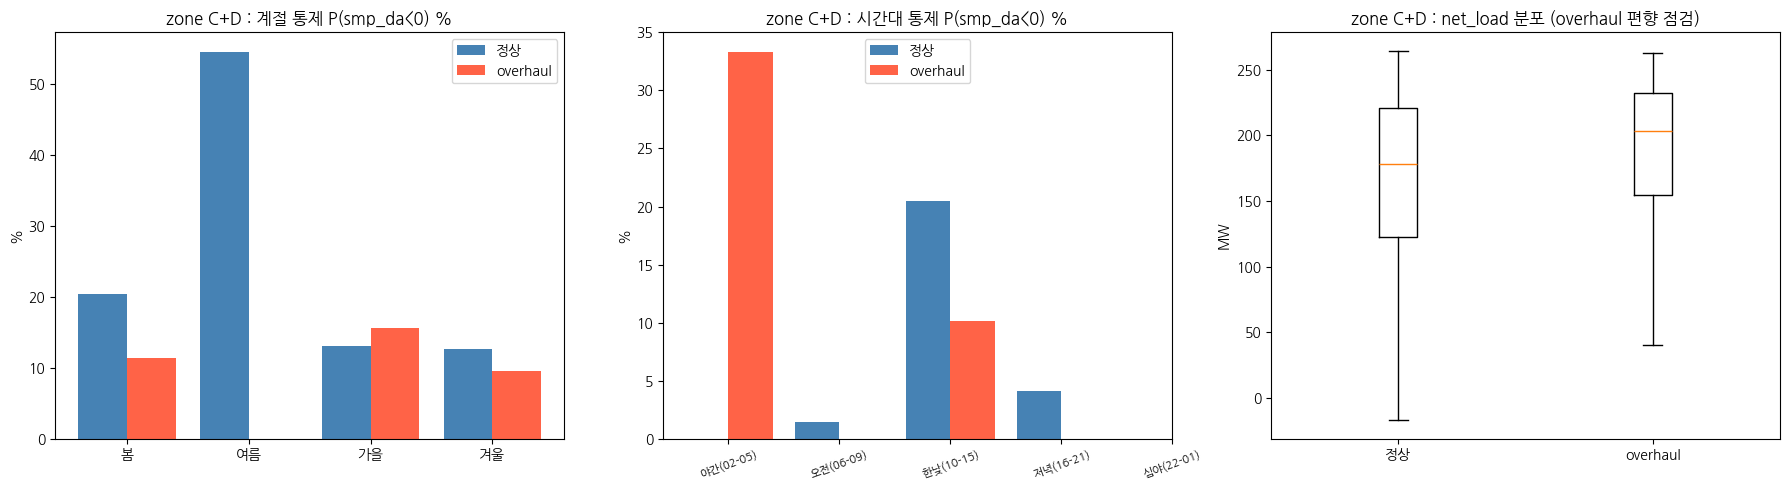

[Step 4-2] overhaul 효과, DA SMP 관점 (zone C+D, 계절x시간 통제) 리포트
zone C+D 표본 : 1403  (overhaul 165 / 정상 1238)
net_load 평균 : overhaul 183.8 vs 정상 168.1 MW (가까울수록 net_load 교란 적음)

[계절 통제 P(smp_da<0) %  (n: overhaul/정상)]
  봄    overhaul   11.4  vs 정상   20.4   (n 44/808)
  여름   overhaul    0.0  vs 정상   54.5   (n 36/11)
  가을   overhaul   15.6  vs 정상   13.1   (n 64/199)
  겨울   overhaul    9.5  vs 정상   12.7   (n 21/220)

[시간대 통제 P(smp_da<0) %  (n: overhaul/정상)]
  야간(02-05)    overhaul   33.3  vs 정상    0.0   (n 6/16)
  오전(06-09)    overhaul    0.0  vs 정상    1.4   (n 8/69)
  한낮(10-15)    overhaul   10.1  vs 정상   20.4   (n 148/1081)
  저녁(16-21)    overhaul    0.0  vs 정상    4.2   (n 3/72)
  심야(22-01)    overhaul    nan  vs 정상    nan   (n 0/0)

[계절x시간 셀 통제] 평균 P(da<5) 차이(overhaul - 정상) = -6.5%p (표본>=5 인 5개 셀, 작은쪽 표본 가중)

-> 차이가 음(-)이면 가설 지지(overhaul 시 floor(smp<5) 감소). 표본 적고 baseline
   center=True(회고용) -> 모델 피처화 시 trailing 재계산 + 약신호로만 사용.


In [7]:
cd = df[df['zone'].isin(['C', 'D'])].copy()


def daypart(h):
    if 2 <= h <= 5:
        return '야간(02-05)'
    if 6 <= h <= 9:
        return '오전(06-09)'
    if 10 <= h <= 15:
        return '한낮(10-15)'
    if 16 <= h <= 21:
        return '저녁(16-21)'
    return '심야(22-01)'


DP_ORDER = ['야간(02-05)', '오전(06-09)', '한낮(10-15)', '저녁(16-21)', '심야(22-01)']

if len(cd):
    cd['daypart'] = cd['hour'].map(daypart)
    ov = cd[cd['overhaul_flag']]
    nov = cd[~cd['overhaul_flag']]

    def pneg_by(col, order):
        sub_o = cd[cd['overhaul_flag']]
        sub_n = cd[~cd['overhaul_flag']]
        out = pd.DataFrame({
            'overhaul': sub_o.groupby(col)['da_neg'].mean() * 100,
            '정상':     sub_n.groupby(col)['da_neg'].mean() * 100,
            'n_ov':     sub_o.groupby(col)['da_neg'].size(),
            'n_nov':    sub_n.groupby(col)['da_neg'].size(),
        }).reindex(order)
        out[['n_ov', 'n_nov']] = out[['n_ov', 'n_nov']].fillna(0).astype(int)
        return out

    by_season = pneg_by('season', SEASON_ORDER)
    by_dp = pneg_by('daypart', DP_ORDER)

    # 계절 x 시간 셀 단위 통제: 둘 다 표본>=5 인 셀만, 작은쪽 표본 가중 평균차이
    rows = []
    for (s, d), g2 in cd.groupby(['season', 'daypart']):
        o = g2[g2['overhaul_flag']]['da_neg']
        nn = g2[~g2['overhaul_flag']]['da_neg']
        if len(o) >= 5 and len(nn) >= 5:
            rows.append((o.mean() - nn.mean(), min(len(o), len(nn))))
    if rows:
        d_arr = np.array([r[0] for r in rows])
        w_arr = np.array([r[1] for r in rows])
        ctrl_diff2 = float(np.average(d_arr, weights=w_arr)) * 100
        n_cells = len(rows)
    else:
        ctrl_diff2, n_cells = float('nan'), 0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    x = np.arange(len(SEASON_ORDER))
    ax.bar(x - 0.2, by_season['정상'].values, 0.4, color='steelblue', label='정상')
    ax.bar(x + 0.2, by_season['overhaul'].values, 0.4, color='tomato', label='overhaul')
    ax.set_xticks(x); ax.set_xticklabels(SEASON_ORDER)
    ax.set_title('zone C+D : 계절 통제 P(smp_da<0) %')
    ax.set_ylabel('%'); ax.legend()

    ax = axes[1]
    x = np.arange(len(DP_ORDER))
    ax.bar(x - 0.2, by_dp['정상'].values, 0.4, color='steelblue', label='정상')
    ax.bar(x + 0.2, by_dp['overhaul'].values, 0.4, color='tomato', label='overhaul')
    ax.set_xticks(x); ax.set_xticklabels(DP_ORDER, rotation=20, fontsize=8)
    ax.set_title('zone C+D : 시간대 통제 P(smp_da<0) %')
    ax.set_ylabel('%'); ax.legend()

    ax = axes[2]
    if len(ov) and len(nov):
        ax.boxplot([nov['net_load'].values, ov['net_load'].values], showfliers=False)
        ax.set_xticks([1, 2]); ax.set_xticklabels(['정상', 'overhaul'])
        ax.set_ylabel('MW')
    else:
        ax.text(0.5, 0.5, 'overhaul/정상 표본 부족', ha='center', va='center')
    ax.set_title('zone C+D : net_load 분포 (overhaul 편향 점검)')

    plt.tight_layout()
    plt.show()

    print('=' * 64)
    print('[Step 4-2] overhaul 효과, DA SMP 관점 (zone C+D, 계절x시간 통제) 리포트')
    print('=' * 64)
    print(f'zone C+D 표본 : {len(cd)}  (overhaul {len(ov)} / 정상 {len(nov)})')
    if len(ov) and len(nov):
        print(f'net_load 평균 : overhaul {ov.net_load.mean():.1f} vs '
              f'정상 {nov.net_load.mean():.1f} MW (가까울수록 net_load 교란 적음)')
    print()
    print('[계절 통제 P(smp_da<0) %  (n: overhaul/정상)]')
    for s in SEASON_ORDER:
        r = by_season.loc[s]
        print(f'  {s:3s}  overhaul {r["overhaul"]:6.1f}  vs 정상 {r["정상"]:6.1f}   '
              f'(n {int(r["n_ov"])}/{int(r["n_nov"])})')
    print()
    print('[시간대 통제 P(smp_da<0) %  (n: overhaul/정상)]')
    for d in DP_ORDER:
        r = by_dp.loc[d]
        print(f'  {d:11s}  overhaul {r["overhaul"]:6.1f}  vs 정상 {r["정상"]:6.1f}   '
              f'(n {int(r["n_ov"])}/{int(r["n_nov"])})')
    print()
    print(f'[계절x시간 셀 통제] 평균 P(da<5) 차이(overhaul - 정상) = {ctrl_diff2:+.1f}%p '
          f'(표본>=5 인 {n_cells}개 셀, 작은쪽 표본 가중)')
    print()
    print('-> 차이가 음(-)이면 가설 지지(overhaul 시 floor(smp<5) 감소). 표본 적고 baseline')
    print('   center=True(회고용) -> 모델 피처화 시 trailing 재계산 + 약신호로만 사용.')
else:
    ctrl_diff2, n_cells = float('nan'), 0
    print('[Step 4] zone C+D 표본이 없음 - Step 3 경계가 퇴화. 경계 재조정 필요.')

## Step 4-3 - 신재생 이용률(renew_util) 축 분석  (신규 피처)

**목표(사용자 추가)**: Step 4-1/4-2(overhaul)와 별개. KPX 출력제어/입찰하한이 신재생
*발전량*보다 capacity 대비 *이용률*에 반응하는지 검증. 이용률은 설비증설(2024->2026)에
불변이라 net_load/renew_share 가 갖는 레짐 혼동이 없다.
- `renew_util_total = real_renew_gen / (Solar_Capacity_Est + Wind_Capacity_Est)`
- `renew_util_solar = Solar_Utilization`,  `renew_util_wind = Wind_Utilization`

Step 1 과 같은 조건부 처리(분위 구간별 P(smp<5)·평균 SMP)에 더해, ① total/solar/wind
중 floor SMP 를 가장 잘 가르는 축을 단일변수 AUC 로 비교(net_load·renew_share 대비),
② net_load zone(B/C/D) 통제 후에도 이용률이 추가 신호를 주는지(3분위) 확인.

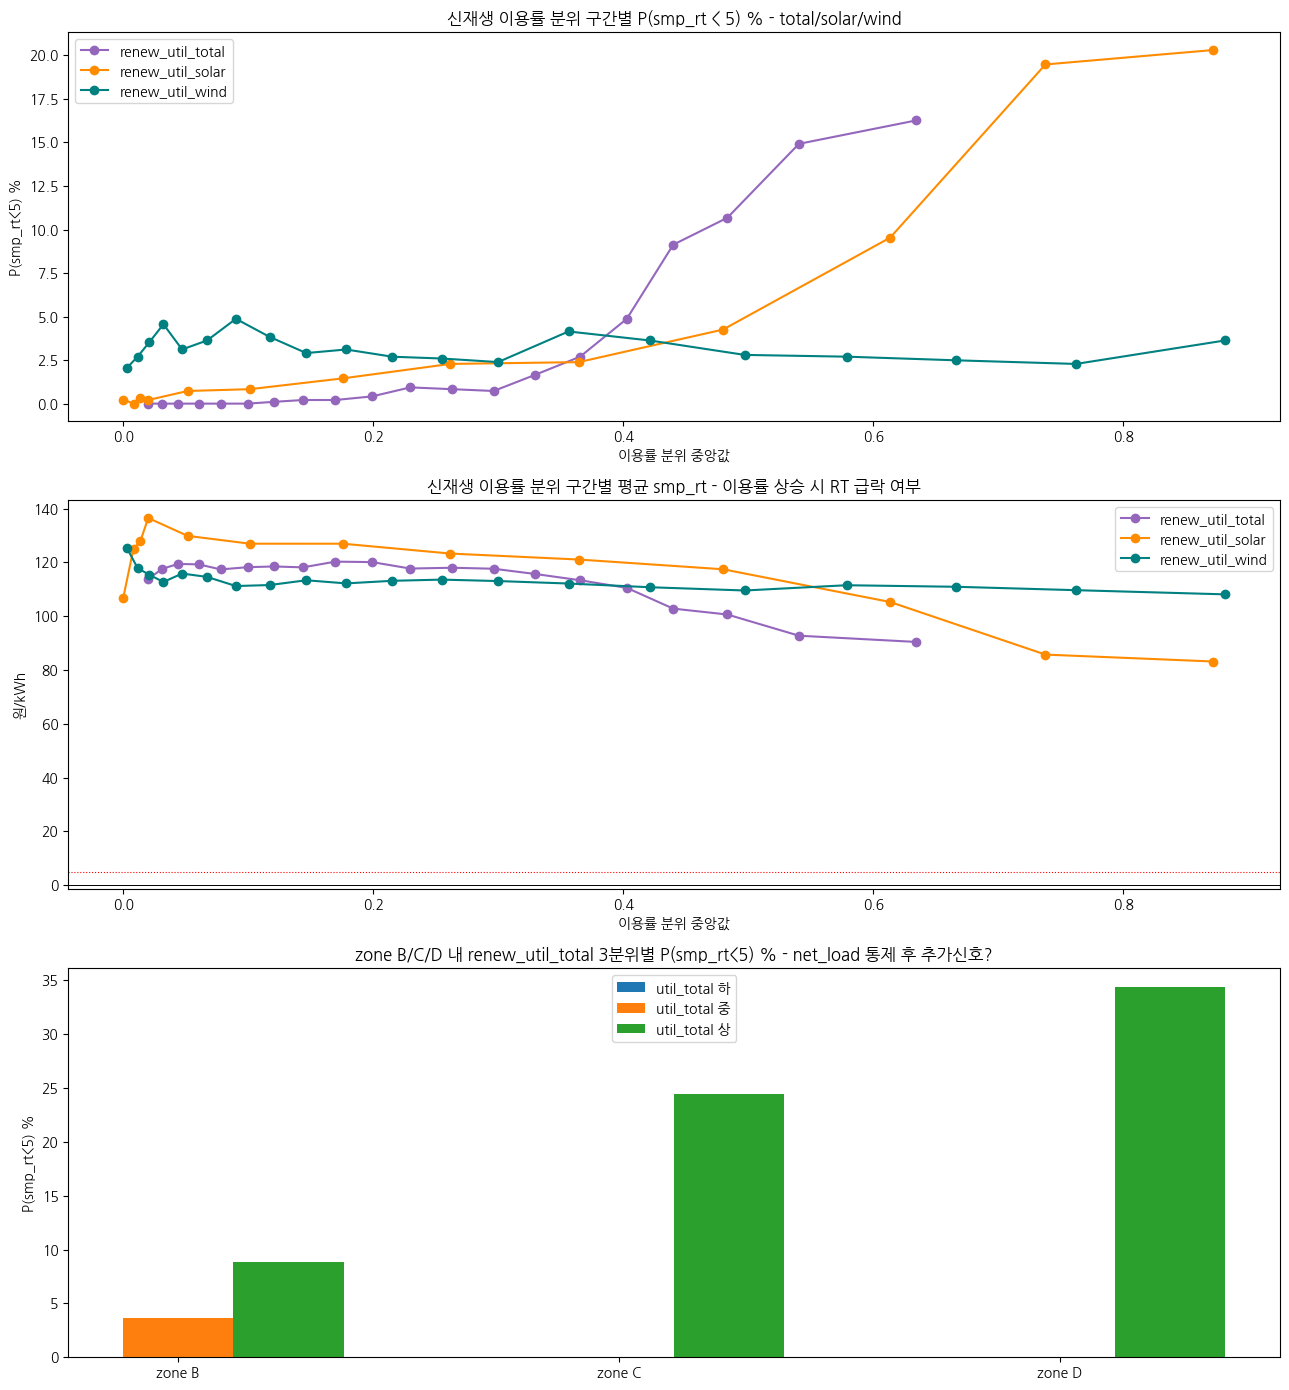

[Step 4-3] 신재생 이용률(renew_util) 축 분석 리포트
[이용률 분포]
  renew_util_total   평균 0.249  중앙 0.214  p95 0.579  max 0.931  결측 0
  renew_util_solar   평균 0.186  중앙 0.016  p95 0.797  max 1.000  결측 0
  renew_util_wind    평균 0.283  중앙 0.196  p95 0.812  max 1.000  결측 0
  (solar 이용률은 야간에 0 값이 많아 -> 곡선 저구간은 야간 혼입, 구조적 0 주의)

[분위 양끝 P(smp_rt<5) % : 최저구간 -> 최고구간]
  renew_util_total     0.0  ->   16.3   (rt_mean 114 -> 90,  bins=20)
  renew_util_solar     0.2  ->   20.3   (rt_mean 107 -> 83,  bins=13)
  renew_util_wind      2.1  ->    3.6   (rt_mean 125 -> 108,  bins=20)

[단일 변수 floor 판별력 AUC (rt_neg<5 예측, >0.5=값 클수록 floor)]
  renew_util_total   AUC=0.881  |분리력|=0.881  (n=19296)
  renew_util_solar   AUC=0.890  |분리력|=0.890  (n=19296)
  renew_util_wind    AUC=0.486  |분리력|=0.514  (n=19296)
  renew_share        AUC=0.929  |분리력|=0.929  (n=19291)
  net_load           AUC=0.065  |분리력|=0.935  (n=19296)
  net_load 는 AUC<0.5 예상(낮을수록 floor) - |분리력| 로 비교.

[zone B/C/D 내 renew_util_total 3분위별 P(smp_rt<5) %  (n)]
  zone 

In [8]:
# ── Step 4-3 (신규 축 피처) : 신재생 이용률(renew_util) vs floor SMP(smp<5) ──
# 가설: KPX 출력제어/입찰하한이 신재생 '발전량'보다 capacity 대비 '이용률'에 반응.
cap_total = df['Solar_Capacity_Est'] + df['Wind_Capacity_Est']
df['renew_util_total'] = (df['real_renew_gen'] / cap_total).replace([np.inf, -np.inf], np.nan)
df['renew_util_solar'] = df['Solar_Utilization'].replace([np.inf, -np.inf], np.nan)
df['renew_util_wind']  = df['Wind_Utilization'].replace([np.inf, -np.inf], np.nan)

UTILS = ['renew_util_total', 'renew_util_solar', 'renew_util_wind']
UCOL  = {'renew_util_total': 'tab:purple',
         'renew_util_solar': 'darkorange',
         'renew_util_wind':  'teal'}


def util_curve(col, nb=20):
    # 이용률 분위 구간별 P(smp_rt<5)/P(smp_jeju<5)/평균 smp_rt (Step 1 과 동일 방식)
    s = df[[col, 'rt_neg', 'da_neg', TARGET]].replace([np.inf, -np.inf], np.nan).dropna(subset=[col])
    s['b'] = pd.qcut(s[col], nb, labels=False, duplicates='drop')
    gg = s.groupby('b')
    return pd.DataFrame({
        'n':       gg.size(),
        'u_med':   gg[col].median(),
        'P_rt':    gg['rt_neg'].mean() * 100,
        'P_da':    gg['da_neg'].mean() * 100,
        'rt_mean': gg[TARGET].mean(),
    }).sort_values('u_med').reset_index(drop=True)


def auc(feat_col, ycol='rt_neg'):
    # 단일변수 floor 판별력 (Mann-Whitney AUC, 동률 평균순위). >0.5 = 값 클수록 floor
    s = df[[feat_col, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    y = s[ycol].astype(int)
    if y.nunique() < 2:
        return float('nan'), len(s)
    r = s[feat_col].rank(method='average')
    npos = int(y.sum()); nneg = len(s) - npos
    a = (r[y == 1].sum() - npos * (npos + 1) / 2) / (npos * nneg)
    return float(a), len(s)


curves = {c: util_curve(c) for c in UTILS}

# net_load zone(B/C/D) 통제 후에도 renew_util_total 이 추가 신호를 주는가 (3분위)
df['util_t_tercile'] = pd.qcut(df['renew_util_total'].rank(method='first'),
                               3, labels=['하', '중', '상'])
TZ   = ['하', '중', '상']
ZBCD = ['B', 'C', 'D']
bc = df[df['zone'].isin(ZBCD)]
zt  = (bc.pivot_table(index='zone', columns='util_t_tercile', values='rt_neg',
                      aggfunc='mean', observed=False) * 100).reindex(index=ZBCD, columns=TZ)
ztn = bc.pivot_table(index='zone', columns='util_t_tercile', values='rt_neg',
                     aggfunc='size', observed=False).reindex(index=ZBCD, columns=TZ)

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

ax = axes[0]
for c in UTILS:
    t = curves[c]
    ax.plot(t['u_med'], t['P_rt'], 'o-', color=UCOL[c], label=c)
ax.set_title('신재생 이용률 분위 구간별 P(smp_rt < 5) % - total/solar/wind')
ax.set_xlabel('이용률 분위 중앙값'); ax.set_ylabel('P(smp_rt<5) %')
ax.legend()

ax = axes[1]
for c in UTILS:
    t = curves[c]
    ax.plot(t['u_med'], t['rt_mean'], 'o-', color=UCOL[c], label=c)
ax.axhline(5, color='red', linestyle=':', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('신재생 이용률 분위 구간별 평균 smp_rt - 이용률 상승 시 RT 급락 여부')
ax.set_xlabel('이용률 분위 중앙값'); ax.set_ylabel('원/kWh')
ax.legend()

ax = axes[2]
x = np.arange(len(ZBCD))
for j, tt in enumerate(TZ):
    ax.bar(x + (j - 1) * 0.25, zt[tt].values, 0.25, label=f'util_total {tt}')
ax.set_xticks(x); ax.set_xticklabels([f'zone {z}' for z in ZBCD])
ax.set_title('zone B/C/D 내 renew_util_total 3분위별 P(smp_rt<5) % - net_load 통제 후 추가신호?')
ax.set_ylabel('P(smp_rt<5) %'); ax.legend()

plt.tight_layout()
plt.show()

print('=' * 64)
print('[Step 4-3] 신재생 이용률(renew_util) 축 분석 리포트')
print('=' * 64)
print('[이용률 분포]')
for c in UTILS:
    u = df[c]
    print(f'  {c:18s} 평균 {u.mean():.3f}  중앙 {u.median():.3f}  '
          f'p95 {u.quantile(.95):.3f}  max {u.max():.3f}  결측 {int(u.isna().sum())}')
print('  (solar 이용률은 야간에 0 값이 많아 -> 곡선 저구간은 야간 혼입, 구조적 0 주의)')
print()
print('[분위 양끝 P(smp_rt<5) % : 최저구간 -> 최고구간]')
for c in UTILS:
    t = curves[c]
    print(f'  {c:18s} {t["P_rt"].iloc[0]:5.1f}  ->  {t["P_rt"].iloc[-1]:5.1f}   '
          f'(rt_mean {t["rt_mean"].iloc[0]:.0f} -> {t["rt_mean"].iloc[-1]:.0f},  bins={len(t)})')
print()
print('[단일 변수 floor 판별력 AUC (rt_neg<5 예측, >0.5=값 클수록 floor)]')
for c in UTILS + ['renew_share', 'net_load']:
    a, nn = auc(c)
    if np.isnan(a):
        print(f'  {c:18s} AUC=NaN')
    else:
        print(f'  {c:18s} AUC={a:.3f}  |분리력|={max(a, 1 - a):.3f}  (n={nn})')
print('  net_load 는 AUC<0.5 예상(낮을수록 floor) - |분리력| 로 비교.')
print()
print('[zone B/C/D 내 renew_util_total 3분위별 P(smp_rt<5) %  (n)]')
for z in ZBCD:
    parts = []
    for tt in TZ:
        p = zt.loc[z, tt]
        n = ztn.loc[z, tt]
        n = int(n) if pd.notna(n) else 0
        parts.append(f'{tt}:{p:.1f}%(n{n})')
    print(f'  zone {z} :  ' + '  '.join(parts))
print()
print('-> 이용률↑ 에 따라 P(smp_rt<5) 가 단조 급상승하고 zone B/C/D 내 3분위 격차도 크면')
print('   renew_util 은 net_load 와 별개의 추가 신호 -> 모델/Phase6 피처 채택.')
print('   total/solar/wind 중 AUC·곡선기울기 최대 축 = KPX 가 반응하는 축.')

## Step 5 - Phase 5 종합 / Phase 6 hand-off

**목표**: zone 지도를 한 화면으로 요약하고, 모델링 시사점·leakage 주의·Phase 6(zone B 날씨
심화) 인계 사항을 정리. 아래 출력 수치는 그대로 `report.ipynb` Phase 5 digest 로 옮긴다.

In [9]:
def _verdict(d):
    if np.isnan(d):
        return '불명확(표본부족/경계퇴화)'
    if abs(d) < 3:
        return f'유의차 없음·노이즈 범위 ({d:+.1f}%p, n 적음)'
    if d < 0:
        return f'감소 경향 ({d:+.1f}%p, 약신호)'
    return f'감소 아님 ({d:+.1f}%p)'

verdict  = _verdict(ctrl_diff)    # RT
verdict2 = _verdict(ctrl_diff2)   # DA

print('=' * 64)
print('[Step 5] Phase 5 종합 - net_load <-> SMP 지도')
print('=' * 64)
print(f'1) floor SMP(smp<5) 는 net_load 0 이 아니라 양(+) 구간에서 시작'
      f' (P=0.05 기준 net_load ~ {nl_at_p(tab, 0.05):.0f} MW).')
print(f'   전체 P(smp_rt<5)={df.rt_neg.mean()*100:.2f}% 인데 net_load<0 은 '
      f'{(df.net_load<0).mean()*100:.2f}% 뿐 -> 경계는 net_load 0 이 아님.')
print(f'2) zone 경계(MW): D < {nl_cuts[0]} <= C < {nl_cuts[1]} '
      f'<= B < {nl_cuts[2]} <= A')
print('   zone 별 P(rt<5)% / P(da<5)% =')
for z in ZONE_ORDER:
    print(f'     {z}: rt {prof.loc[z, "P_rt_neg%"]:.1f}%  '
          f'da {prof.loc[z, "P_da_neg%"]:.1f}%  '
          f'(n {int(prof.loc[z, "n"])}, {prof.loc[z, "share_%"]:.1f}%)')
print('   * 결정적 zone 없음: 최저 net_load·zone D 도 P 상한 ~34% (나머지는 날씨=Phase6).')
print('3) DA(smp_jeju) floor 비율은 전 zone 에서 RT 보다 훨씬 낮음'
      ' -> DA 단독으로 floor 거의 못 잡음(보정모델 필수).')
print(f'4-1) overhaul (zone C+D, 계절x시간 통제) RT: P(rt<5) 차이 = {ctrl_diff:+.1f}%p -> {verdict}')
print(f'4-2) overhaul (zone C+D, 계절x시간 통제) DA: P(da<5) 차이 = {ctrl_diff2:+.1f}%p -> {verdict2}')
print('   해석: RT 는 계절통제 시 부호 불일치=노이즈, DA 는 일관 감소. overhaul 은 DA(전일')
print('   capacity 희소성 반영)만 띄우고 RT(실현 신재생 과잉)는 못 막음 -> overhaul 중 DA-RT')
print('   격차 확대. overhaul_flag = floor 억제가 아닌 baseline 악화 신호 (Phase4 와 일관).')
print()
print('[모델링 시사점]')
print(' - baseline = DA(smp_jeju) + zone 더미 + net_load. zone A(84%)는 DA 거의 그대로.')
print(' - zone B(전이) = 보정 핵심. 잔차는 Phase 6 의 태양광 중심 실시간 날씨로 설명.')
print(' - floor(<5) 는 분리 분류기(occurrence) + 회귀(level) 권장. zone D 도 비결정적(P~34%).')
print(' - leakage: net_load/renew 류는 실측(예측시 미지) -> est_demand + 신재생예측 기반')
print('   forecast 축 필요. overhaul_flag 는 center=True(회고) -> trailing 재계산·약신호.')
print()
print('-> Phase 6 (eda6.ipynb): zone B/C/D 잔여 ~2/3 불확실성을 태양광 중심 실시간 날씨로')
print('   분해 (zone내 분위·계절x시간 통제). 풍력은 floor 아닌 분산/크기; 야간은 풍력축.')

[Step 5] Phase 5 종합 - net_load <-> SMP 지도
1) floor SMP(smp<5) 는 net_load 0 이 아니라 양(+) 구간에서 시작 (P=0.05 기준 net_load ~ 384 MW).
   전체 P(smp_rt<5)=3.18% 인데 net_load<0 은 0.11% 뿐 -> 경계는 net_load 0 이 아님.
2) zone 경계(MW): D < 181.3 <= C < 264.5 <= B < 383.6 <= A
   zone 별 P(rt<5)% / P(da<5)% =
     A: rt 0.5%  da 0.1%  (n 16295, 84.4%)
     B: rt 8.0%  da 3.4%  (n 1598, 8.3%)
     C: rt 24.3%  da 11.0%  (n 703, 3.6%)
     D: rt 34.1%  da 23.6%  (n 700, 3.6%)
   * 결정적 zone 없음: 최저 net_load·zone D 도 P 상한 ~34% (나머지는 날씨=Phase6).
3) DA(smp_jeju) floor 비율은 전 zone 에서 RT 보다 훨씬 낮음 -> DA 단독으로 floor 거의 못 잡음(보정모델 필수).
4-1) overhaul (zone C+D, 계절x시간 통제) RT: P(rt<5) 차이 = -1.2%p -> 유의차 없음·노이즈 범위 (-1.2%p, n 적음)
4-2) overhaul (zone C+D, 계절x시간 통제) DA: P(da<5) 차이 = -6.5%p -> 감소 경향 (-6.5%p, 약신호)
   해석: RT 는 계절통제 시 부호 불일치=노이즈, DA 는 일관 감소. overhaul 은 DA(전일
   capacity 희소성 반영)만 띄우고 RT(실현 신재생 과잉)는 못 막음 -> overhaul 중 DA-RT
   격차 확대. overhaul_flag = floor 억제가 아닌 baseline 악화 신호 (Phase4 와 일관).

[모델링 시사점]
 - baseline = DA(s

## Phase 5 요약

(최종 수치는 위 Step 5 출력 -> `report.ipynb` Phase 5 digest 로 정리)

- **Step 0** — net_load·renew_share·gap·floor(smp<5)·overhaul_flag 정의, 윈도/결측/커버리지 점검.
- **Step 1** — net_load 20분위별 P(smp_rt<5)·P(smp_jeju<5)·평균 SMP 곡선. RT 음전환이
  net_load 0 이 아닌 양(+) 구간에서 시작함을 확인, zone 경계 단서(P 교차 net_load) 추출.
- **Step 2** — 계절 x 시간 히트맵(P(rt<5)·net_load·격차 평균/std). 봄/가을 한낮 집중 재확인.
- **Step 3** — P 곡선에서 데이터기반 net_load 경계로 zone A/B/C/D 분할, 프로파일·계절구성표.
- **Step 4** — zone C+D 에서 overhaul vs 정상 P(rt<5) 를 계절·시간대 통제 비교(사용자 가설).
- **Step 5** — 종합·모델링 시사점·leakage 주의·Phase 6(zone B 날씨 심화) 인계.